In [6]:
import sys
sys.path.append('./src')

import time
import json
from datetime import datetime
from copy import deepcopy

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
# from gigalens.jax.physical_model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles import mass, light

import tensorflow_probability.substrates.jax as tfp
import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
import matplotlib as mpl
from matplotlib import pyplot as plt
import optax

from astropy.io import fits
from astropy.table import Table
from astropy.visualization import simple_norm
from skimage.measure import block_reduce

from corner import corner
tfd = tfp.distributions
tfe = tfp.experimental

# import boiler

In [9]:
# from gigalens.jax.cosmo import wCDM_Cosmo, w0waCDM_Cosmo
# from gigalens.jax.prior import Prior, make_prior_and_model

z_lens = 0.5
z_source1 = z_lens*2
z_source2 = z_lens*3

lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.5), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(-0.3, 0.15),
                center_y=tfd.Normal(-0.1, 0.15),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.15), gamma2=tfd.Normal(0, 0.15))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(2, 6),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(-0.3, 0.05),
                center_y=tfd.Normal(-0.1, 0.05),
                Ie=tfd.LogNormal(jnp.log(30), 0.5),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(4, 8),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(-0.3, 0.05),
                center_y=tfd.Normal(-0.1, 0.05),
                Ie=tfd.LogNormal(jnp.log(30), 0.5),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(24, 28),
                e1=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                center_x=tfd.Normal(-3.4, 0.25),
                center_y=tfd.Normal(-3.1, 0.25),
                Ie=tfd.LogNormal(jnp.log(30), 0.5),
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(-0.2, 0.25),
                center_y=tfd.Normal(-0.2, 0.25),
                Ie=tfd.LogNormal(jnp.log(20.0), 0.5),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(0.2, 0.25),
                center_y=tfd.Normal(0, 0.25),
                Ie=tfd.LogNormal(jnp.log(20.0), 0.5),
            )
        )
    ]
)

prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

In [10]:
source1.params.keys()

NameError: name 'source1' is not defined

In [11]:
source1.profile.params

NameError: name 'source1' is not defined

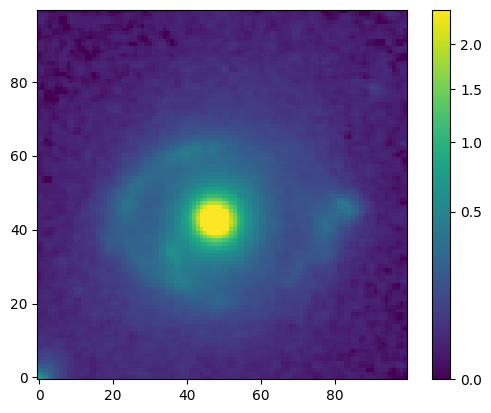

In [19]:
# TODO: Change to point to local directory
from astropy.io import fits
from astropy.visualization import simple_norm

data94 = fits.open("final_94_drz.fits")
image94 = data94[1].data
exp_time = data94[0].header["EXPTIME"]
data94.close()

system = np.array(np.load('./imL.npy')).astype(np.float32)

norm = simple_norm(system, "sqrt", percent=99.)
plt.imshow(system, norm=norm, cmap="viridis", origin='lower')
plt.colorbar()

# epsfdata = fits.open("./desi238/psf238.fits")
# epsf = epsfdata[0].data
# epsfdata.close()
from gigalens.jax.profiles.mass import epl, shear

kernel = np.array(np.load('./psf.npy')).astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=100, supersample=2, kernel=kernel)
# phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], 
                          #  [sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False)], 
                          #  [sersic.SersicEllipse(use_lstsq=False), sersic.SersicEllipse(use_lstsq=False)],
                          #  None,
                          #  None
                          # )
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False), sersic.SersicEllipse(use_lstsq=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
observed_img = system
background_rms = 0.007616264 #background_rms from photutils.background
prob_model = ForwardProbModel(prior, jnp.array(observed_img), background_rms=background_rms, exp_time=exp_time)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

# MAP

In [21]:
schedule_fn = optax.polynomial_schedule(init_value=1e-2, end_value=1e-4, power=0.5, transition_steps=1000)
opt = optax.adabelief(schedule_fn, b1=0.95, b2=0.99, nesterov=True)
best, lps, chisq = model_seq.MAP(optimizer=opt, num_steps=450, n_samples=1000, pbar_interval=50)

  0%|          | 0/1000 [01:33<?, ?it/s]
2026-07-02 22:23:29.478623: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng35{k2=1,k5=3,k14=2} for conv %cudnn-conv = (f32[250,1,200,200]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.61, %constant.10799), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_name="jit(run_map)/jit(main)/jit(shmap_body)/while/body/jit(loss)/jvp(jit(log_prob))/jit(simulate)/conv_general_dilated" source_file="/tmp/ipykernel_385938/767026351.py" source_line=3}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
  0%|          | 0/450 [00:17<?, ?it/s]2026-07-02 22:23:32.836013: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.357460979s
Try

Final Chi-squared: 1.04444


In [ ]:
plt.plot(chisq)

  0%|          | 0/1000 [00:10<?, ?it/s]

# SVI

In [22]:
schedule_fn = optax.polynomial_schedule(init_value=1e-4, end_value=1e-4, power=0.5, transition_steps=1000)
opt = optax.adabelief(schedule_fn, b1=0.95, b2=0.99)
qz, loss = model_seq.SVI(best, optimizer=opt, num_steps=1500, n_vi=1000, pbar_interval=100)

  0%|          | 0/1500 [00:11<?, ?it/s]2026-07-02 22:25:04.028162: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-02 22:25:04.028192: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
-ELBO: -30695.102: 100%|██████████| 1500/1500 [02:46<00:00,  8.99it/s]


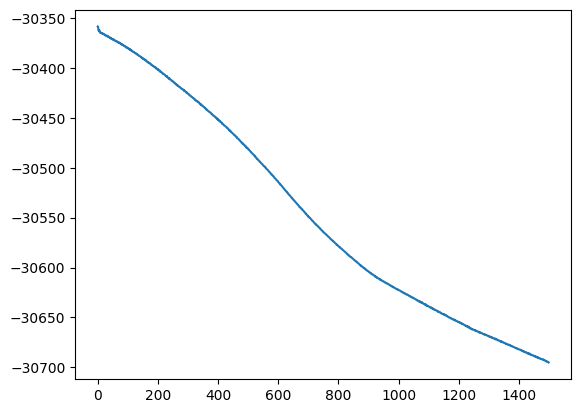

In [23]:
plt.plot(loss)

### Variance self-correction and loading labels

In [24]:
mean = np.array(qz.mean())
covariance = np.array(qz.covariance())
qz_corrected = tfd.MultivariateNormalFullCovariance(loc=mean, covariance_matrix=covariance)

2026-07-02 22:27:35.768142: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


In [25]:
labels = jax.tree.map_with_path(lambda path, _: jax.tree_util.keystr(path, simple=True, separator=' '), prior.sample(1, jax.random.key(0)))
labels = jax.tree.leaves(labels)

# MCLMC

In [ ]:
sys.path.append('./wip')
from importlib import reload

In [39]:
import mclmc_alt as mclmc
reload(mclmc)

t = time.time()
print(datetime.now())
samples_MCLMC = mclmc.MCLMC(model_seq, 
                              qz_corrected,
                              n_hmc=48, 
                              num_burnin_steps=250, 
                              num_results=750, 
                              seed=1,
                              progress_bar=True
                         ).transpose(1,0,2)
# MCLMC(model_seq, qz, n_hmc=16, num_burnin_steps=1000, num_results=2000, mass_matrix_adapt=True,
#         init_L=None, init_step_size=None, progress_bar=False, print_adapt_params=False,seed=0)

t_sample = time.time() - t
print(f'MCLMC time: {t_sample / 60:.1f} min')
print(samples_MCLMC.shape)

2026-07-02 10:39:43.242343
Stage 2 Cov Egval Mean: (0.0494832880795002+0j), Min: (8.700903464387011e-08+0j), Max: (1.4277219772338867+0j)
Burnin Time: 80.5209804509941


<div><progress max="750" value="750"></progress> 100.00% [750/750 00:00&lt;?]</div>

Sampling took 48.516071970021585 s
MCLMC time: 2.5 min
(48, 750, 43)


In [40]:
samples_MCLMC = samples

In [44]:
rhat_MCLMC = tfp.mcmc.potential_scale_reduction(samples_MCLMC,independent_chain_ndims=1)
ess_MCLMC = tfp.mcmc.effective_sample_size(samples_MCLMC, cross_chain_dims=(1))
rhat_MCLMC, ess_MCLMC

(Array([1.0042261 , 1.0065405 , 0.9953099 , 0.9945077 , 1.0011051 ,
        0.9966247 , 0.99541205, 1.0770452 , 1.0842332 , 1.0104918 ,
        0.99869573, 1.0195059 , 1.0475844 , 1.0588444 , 1.0726203 ,
        1.0518857 , 1.0025276 , 1.0074682 , 1.0389737 , 1.0728701 ,
        1.0550623 , 1.0123082 , 0.99801946, 1.0053382 , 0.9912597 ,
        1.0002228 , 0.9996904 , 1.0010111 , 0.99262995, 0.99218124,
        0.99936795, 0.9984237 , 0.99455875, 1.0045873 , 0.99752134,
        0.99058056, 0.99312747, 0.99379146, 1.0006745 , 1.001079  ,
        1.003388  , 0.9965575 , 0.9970535 ], dtype=float32),
 Array([36000.004, 32325.648, 36000.   , 36000.004, 36000.   , 36000.   ,
        36000.   ,  9968.354,  8482.878, 36000.   , 36000.008, 20039.275,
        27422.857, 11977.334, 10711.64 , 16762.965, 36000.004, 31056.617,
        19236.395, 10550.288, 13264.208, 35484.67 , 36000.   , 36000.   ,
        36000.016, 36000.   , 35999.992, 36000.   , 36000.   , 36000.   ,
        36000.01 , 35999.

In [50]:
physical_samples_MCLMC = prob_model.bij.forward(samples_MCLMC[::50].reshape(-1,len(rhat_MCLMC)).T.tolist())

In [51]:
corner(np.array(jax.tree.leaves(physical_samples_MCLMC))[:10].T, show_titles=True, labels=labels, title_fmt='.3f')
plt.show()

<Figure size 9160x9160 with 1849 Axes>

# MAMS

In [27]:
import sys
sys.path.append('../mams')
import mams

t = time.time()
print(datetime.now())
samples_MAMS = mams.MAMS(model_seq, 
                         qz_corrected,
                         n_hmc=48, 
                         num_burnin_steps=250, 
                         num_results=750, 
                         seed=1,
                         progress_bar=True,
                         mass_matrix_adapt = False
                         ).transpose(1,0,2)

t_sample = time.time() - t
print(f'MAMS time: {t_sample / 60:.1f} min')
print(samples_MAMS.shape)

2026-07-02 22:27:44.840362


2026-07-02 22:27:45.512319: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-02 22:27:53.386183: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng36{k2=5,k13=1,k14=3,k18=1,k23=0} for conv %cudnn-conv = (f32[48,1,200,200]{3,2,1,0}, u8[0]{0}) custom-call(%select.854, %constant.883), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_name="jit(<lambda>)/jit(main)/vmap(jvp(jit(log_prob)))/jit(simulate)/conv_general_dilated" source_file="/global/u1/c/chaseg/desi-238/../mams/mams.py" source_line=276}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_

Burnin Time: 27.365076007990865


2026-07-02 22:28:32.988325: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-02 22:28:32.988352: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


<div><progress max="750" value="750"></progress> 100.00% [750/750 00:00&lt;?]</div>

Sampling took 46.39457370300079 s
MAMS time: 1.5 min
(48, 750, 43)


In [31]:
rhat_MAMS = tfp.mcmc.potential_scale_reduction(samples_MAMS.transpose(1,0,2),independent_chain_ndims=1)
ess_MAMS = tfp.mcmc.effective_sample_size(samples_MAMS, cross_chain_dims=(1))
rhat_MAMS, ess_MAMS

(Array([1.1129396, 1.0652034, 1.1782659, 1.2295295, 1.4252917, 1.1709596,
        1.2211782, 1.2745142, 4.958452 , 4.2986207, 1.1558399, 1.2354591,
        1.9452307, 2.3917677, 2.7673812, 4.1155133, 4.6363125, 1.0296961,
        1.1481252, 1.238305 , 1.795255 , 4.4801035, 3.4084468, 2.756163 ,
        2.2182753, 2.3204174, 1.1476629, 2.3712156, 1.0916088, 1.0737237,
        1.2015055, 1.4098784, 1.214148 , 1.0484036, 1.0554045, 3.0410333,
        1.2173085, 1.3174155, 1.1929063, 1.1310629, 1.0884393, 1.0818057,
        1.17868  ], dtype=float32),
 Array([33366.793, 36000.   , 36000.   , 30963.445, 33908.926, 36000.   ,
        36000.   , 36000.   , 26546.312, 25047.633, 36000.   , 35987.508,
        29049.629, 29239.908, 36000.   , 36000.   , 33155.227, 36000.   ,
        28929.51 , 34371.94 , 34991.566, 36000.   , 30926.574, 32477.773,
        36000.   , 36000.   , 36000.   , 29305.494, 36000.   , 34650.855,
        31920.398, 33824.98 , 33825.57 , 32486.416, 35312.996, 36000.   ,
  

In [32]:
physical_samples_MAMS = prob_model.bij.forward(samples_MAMS[::50].reshape(-1,len(rhat_MAMS)).T.tolist())

In [ ]:
corner(np.array(jax.tree.leaves(physical_samples_MCLMC))[:10].T, show_titles=True, labels=labels, title_fmt='.3f')
plt.show()

In [63]:
plt.plot(samples[...,0])
plt.show()

<Figure size 640x480 with 1 Axes>

In [64]:
plt.plot(samples[...,1])
plt.show()

<Figure size 640x480 with 1 Axes>